In [1]:
# %%
# =============================================================================
#  Quad4  –  Bilinear Quadrilateral  (4 nodes · 8 DOF)
#  Complete notebook – follows CST/LST reference structure exactly
# =============================================================================
#
#  Node layout (CCW):
#
#   4 ----3
#   |      |
#   |      |
#   1 ----2
#
#  Reference element:  ξ ∈ [-1,1],  η ∈ [-1,1]
#  N1 = (1-ξ)(1-η)/4,  N2 = (1+ξ)(1-η)/4
#  N3 = (1+ξ)(1+η)/4,  N4 = (1-ξ)(1+η)/4
#  B-matrix requires numerical integration (Gauss quadrature)

import numpy as np
from numpy.polynomial.legendre import leggauss

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Polygon
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import clear_output
from ipywidgets import interact, FloatSlider, IntSlider, fixed

np.set_printoptions(precision=4, suppress=True, linewidth=200)

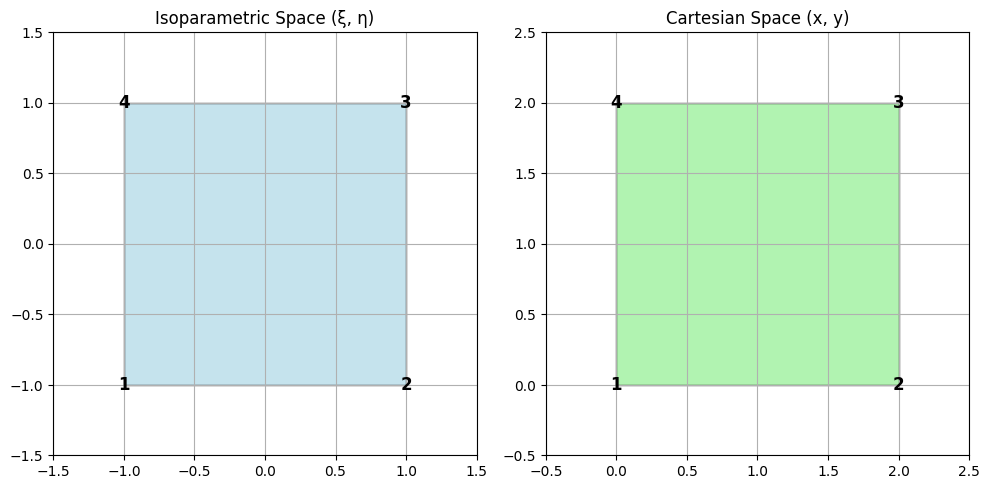

In [2]:
# Define nodal coordinates

# Cartesian coordinates (irregular quad)
# nodes_cartesian = np.array([
#     [0.0, 0.0],    # Node 1
#     [2.0, -1],    # Node 2
#     [2.5, 1.5],    # Node 3
#     [0.2, 1.8]     # Node 4
# ])

nodes_cartesian = np.array([
    [0,0],    # Node 1
    [2,0],    # Node 2
    [2,2],    # Node 3
    [0,2],    # Node 4
])

# Isoparametric coordinates
nodes_iso = np.array([
    [-1.0, -1.0],  # Node 1
    [ 1.0, -1.0],  # Node 2
    [ 1.0,  1.0],  # Node 3
    [-1.0,  1.0]   # Node 4
])

# Material properties
E=210e9  # Young's modulus in Pa
nu=0.3  # Poisson's ratio
t=0.01  # Thickness in m

# Plot setup
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Plot Isoparametric space
ax1 = axes[0]
patch_iso = Polygon(nodes_iso, closed=True, edgecolor='black', facecolor='lightblue', alpha=0.7)
ax1.add_patch(patch_iso)
for i, (x, y) in enumerate(nodes_iso, 1):
    ax1.text(x, y, f'{i}', ha='center', va='center', fontsize=12, weight='bold')
ax1.set_title('Isoparametric Space (ξ, η)')
ax1.set_xlim(-1.5, 1.5)
ax1.set_ylim(-1.5, 1.5)
ax1.set_aspect('equal')
ax1.grid(True)

# Plot Cartesian space
ax2 = axes[1]
patch_cart = Polygon(nodes_cartesian, closed=True, edgecolor='black', facecolor='lightgreen', alpha=0.7)
ax2.add_patch(patch_cart)
for i, (x, y) in enumerate(nodes_cartesian, 1):
    ax2.text(x, y, f'{i}', ha='center', va='center', fontsize=12, weight='bold')
ax2.set_title('Cartesian Space (x, y)')
ax2.set_xlim(-0.5, 2.5)
ax2.set_ylim(-0.5, 2.5)
ax2.set_aspect('equal')
ax2.grid(True)

plt.tight_layout()
plt.show()

In [3]:
# ----------------------------------
# Shape functions and their derivatives
# ----------------------------------
def shape_functions(xi, eta):
    N1 = 0.25 * (1 - xi) * (1 - eta)
    N2 = 0.25 * (1 + xi) * (1 - eta)
    N3 = 0.25 * (1 + xi) * (1 + eta)
    N4 = 0.25 * (1 - xi) * (1 + eta)
    return np.array([[N1], [N2], [N3], [N4]])

def shape_function_derivatives(xi, eta):
    dN_dxi = np.array([
        [-0.25 * (1 - eta)],
        [ 0.25 * (1 - eta)],
        [ 0.25 * (1 + eta)],
        [-0.25 * (1 + eta)]
    ]).flatten()

    dN_deta = np.array([
        [-0.25 * (1 - xi)],
        [-0.25 * (1 + xi)],
        [ 0.25 * (1 + xi)],
        [ 0.25 * (1 - xi)]
    ]).flatten()

    return dN_dxi, dN_deta

# -------------------------------
# Jacobian matrix and determinant
# -------------------------------
def jacobian_matrix(coords, xi, eta):
    dN_dxi, dN_deta = shape_function_derivatives(xi, eta)
    J = np.zeros((2, 2))
    for i in range(4):
        J[0, 0] += dN_dxi[i] * coords[i, 0]  # dx/dxi
        J[0, 1] += dN_dxi[i] * coords[i, 1]  # dy/dxi
        J[1, 0] += dN_deta[i] * coords[i, 0]  # dx/deta
        J[1, 1] += dN_deta[i] * coords[i, 1]  # dy/deta
    return J

def jacobian_determinant(J):
    return np.linalg.det(J)

# ----------------------------------------
# Partial derivatives with respect to x, y
# ----------------------------------------
def shape_function_derivatives_global(coords, xi, eta):
    dN_dxi, dN_deta = shape_function_derivatives(xi, eta)
    J = jacobian_matrix(coords, xi, eta)
    J_inv = np.linalg.inv(J)

    dN_dx = []
    dN_dy = []
    for i in range(4):
        dN_nat = np.array([dN_dxi[i], dN_deta[i]])
        dN_phys = J_inv @ dN_nat
        dN_dx.append(dN_phys[0])
        dN_dy.append(dN_phys[1])
    return np.array(dN_dx), np.array(dN_dy)

# ---------------------------
# B matrix (Strain-Displacement)
# ---------------------------
def strain_displacement_matrix(coords, xi, eta):
    dN_dx, dN_dy = shape_function_derivatives_global(coords, xi, eta)
    B = np.zeros((3, 8))
    for i in range(4):
        B[0, 2*i]     = dN_dx[i]  # ε_x
        B[1, 2*i + 1] = dN_dy[i]  # ε_y
        B[2, 2*i]     = dN_dy[i]  # γ_xy
        B[2, 2*i + 1] = dN_dx[i]
    return B

def generalized_interpolation(xi, eta, data_matrix):
    N = shape_functions(xi, eta)
    return (data_matrix @ N).flatten()

# -------------------------------
# Utility: Axis limits
# -------------------------------

def get_limits(coords, margin=0.5):
    x_min, y_min = np.min(coords, axis=0)
    x_max, y_max = np.max(coords, axis=0)
    return (x_min - margin, x_max + margin), (y_min - margin, y_max + margin)

def annotate_top_right(ax, value, fmt='.4f'):
    ax.annotate(
        f'{value:{fmt}}',
        xy=(0.98, 0.98),
        xycoords='axes fraction',
        fontsize=10,
        ha='right',
        va='top',
        bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8)
    )

def compute_element_area(coords):
    x = coords[:, 0]
    y = coords[:, 1]
    # Shoelace formula for polygon area
    area = 0.5 * abs(
        x[0]*y[1] + x[1]*y[2] + x[2]*y[3] + x[3]*y[0] -
        (y[0]*x[1] + y[1]*x[2] + y[2]*x[3] + y[3]*x[0])
    )
    return area

def constitutive_matrix(E=210e3, nu=0.3):
    coef = E / (1 - nu**2)
    return coef * np.array([
        [1,     nu,    0],
        [nu,    1,     0],
        [0,     0, (1 - nu) / 2]
    ])

def integrand_trace(coords, xi, eta, E_mat, t=1.0):
    """Compute trace of B^T E B * |J| at a given xi, eta"""
    B = strain_displacement_matrix(coords, xi, eta)
    J = jacobian_matrix(coords, xi, eta)
    detJ = jacobian_determinant(J)
    K_local = B.T @ E_mat @ B
    return t * detJ * np.trace(K_local)

def compute_integrand_matrix(coords, xi, eta, E_mat, t=1.0):
    
    B = strain_displacement_matrix(coords, xi, eta)
    J = jacobian_matrix(coords, xi, eta)
    detJ = jacobian_determinant(J)

    return t * detJ * (B.T @ E_mat @ B)

def simpson_2d(f_grid, h_xi, h_eta):
    """
    Applies the composite 2D Simpson's rule to a grid f_grid.
    Assumes an odd number of points (e.g., 51 x 51).
    """
    if f_grid.shape[0] % 2 == 0 or f_grid.shape[1] % 2 == 0:
        raise ValueError("Simpson's rule requires an odd number of points in each dimension.")

    m, n = f_grid.shape
    S = 0

    for i in range(m):
        for j in range(n):
            coef_i = 2 + 2*(i % 2)
            coef_j = 2 + 2*(j % 2)
            if i == 0 or i == m-1:
                coef_i = 1
            if j == 0 or j == n-1:
                coef_j = 1
            S += coef_i * coef_j * f_grid[i, j]

    return (h_xi * h_eta / 9) * S

def gauss_points(n):
    """
    Returns Gauss-Legendre quadrature points and weights for [-1, 1].
    """
    pts_1d, _ = leggauss(n)
    Xi, Eta = np.meshgrid(pts_1d, pts_1d)
    return np.column_stack((Xi.flatten(), Eta.flatten()))

def gauss_points(n):
    """
    Returns a list of Gauss points in [-1, 1]^2 with their combined weights.

    Returns:
    - points: array of shape (n^2, 2)
    - weights: array of shape (n^2,)
    """
    pts_1d, w_1d = leggauss(n)
    Xi, Eta = np.meshgrid(pts_1d, pts_1d)
    Wxi, Weta = np.meshgrid(w_1d, w_1d)
    points = np.column_stack((Xi.flatten(), Eta.flatten()))
    weights = (Wxi * Weta).flatten()
    return points, weights

def gauss_integrate_component(func, idx, coords, E_mat, n_gauss):
    """
    Integrates K_{ii}(xi, eta) over the domain using 2D Gauss-Legendre quadrature.

    - func: function compute_integrand_matrix
    - idx: component index K_{ii}
    - coords: element coordinates
    - E_mat: constitutive matrix
    - n_gauss: quadrature order (e.g., 2 → 2x2 points)

    Returns:
    - integral (float)
    """
    pts_1d, w_1d = leggauss(n_gauss)
    integral = 0.0
    for i in range(n_gauss):
        for j in range(n_gauss):
            xi = pts_1d[i]
            eta = pts_1d[j]
            w = w_1d[i] * w_1d[j]

            K_local = func(coords, xi, eta, E_mat)
            integral += w * K_local[idx, idx]

    return integral

# -------------------------------
#  STIFFNESS MATRIX 
# -------------------------------

def compute_stiffness_matrix(coords, E=210e9, nu=0.3, t=1.0, n_gauss=2):
    E_mat = constitutive_matrix(E, nu)
    points, weights = gauss_points(n_gauss)
    K = np.zeros((8, 8))

    for (xi, eta), w in zip(points, weights):
        B = strain_displacement_matrix(coords, xi, eta)
        J = jacobian_matrix(coords, xi, eta)
        detJ = jacobian_determinant(J)
        K += B.T @ E_mat @ B * detJ * t * w

    return K

def check_symmetry(K, tol=1e-6):
    """
    Checks the symmetry of the stiffness matrix.

    Returns the maximum absolute error between K and its transpose.
    """
    error = np.max(np.abs(K - K.T))
    return error

def rigid_body_modes():
    """
    Returns displacement vectors for rigid body modes:
    - Translation in x
    - Translation in y
    - Rotation around the centroid
    """
    ux = np.array([1, 0]*4)  # [1,0,1,0,...]
    uy = np.array([0, 1]*4)  # [0,1,0,1,...]

    # Nodal positions (x, y)
    cx, cy = nodes_cartesian.mean(axis=0)
    rot = []
    for x, y in nodes_cartesian:
        rot += [-(y - cy), (x - cx)]
    rot = np.array(rot)

    return ux, uy, rot

def internal_energy(K, u):
    """
    Computes the internal energy U = 0.5 * uᵀ K u
    """
    return 0.5 * u.T @ K @ u

def verify_rigid_body_modes(K, verbose=True):
    """
    Evaluates internal energy for the 3 rigid body modes and displays results.
    """
    ux, uy, rot = rigid_body_modes()

    e_x = internal_energy(K, ux)
    e_y = internal_energy(K, uy)
    e_r = internal_energy(K, rot)
    sym_err = check_symmetry(K)

    if verbose:
        print(f"Symmetry error: {sym_err:.6e} (should be ~0)")
        print(f"Energy for x-translation: {e_x:.6e}")
        print(f"Energy for y-translation: {e_y:.6e}")
        print(f"Energy for rotation: {e_r:.6e}")

    return sym_err, e_x, e_y, e_r

In [4]:
def plot_mapping(xi, eta):
    clear_output(wait=True)
    data_matrix = np.vstack([nodes_cartesian[:, 0], nodes_cartesian[:, 1]])
    x_mapped, y_mapped = generalized_interpolation(xi, eta, data_matrix)
    iso_xlim, iso_ylim   = get_limits(nodes_iso,       0.2)
    cart_xlim, cart_ylim = get_limits(nodes_cartesian, 0.5)

    fig = plt.figure(figsize=(20, 10), dpi=100, constrained_layout=True)
    gs  = fig.add_gridspec(2, 5, height_ratios=[1.1, 1])

    ax1    = fig.add_subplot(gs[0, 0])
    ax2    = fig.add_subplot(gs[0, 1])
    axB    = fig.add_subplot(gs[0, 2:5])
    axs_sf = [fig.add_subplot(gs[1, i]) for i in range(4)]

    # --- Isoparametric view ---
    ax1.add_patch(Polygon(nodes_iso, closed=True, edgecolor='black', facecolor='lightblue', alpha=0.6))
    for i, (x, y) in enumerate(nodes_iso, 1):
        ax1.text(x, y, str(i), ha='center', va='center', fontsize=12, fontweight='bold')
    ax1.plot(xi, eta, 'ro', markersize=10)
    ax1.set_title('Isoparametric Space $(\\xi, \\eta)$', fontsize=12)
    ax1.set_xlim(*iso_xlim); ax1.set_ylim(*iso_ylim)
    ax1.set_aspect('equal'); ax1.grid(True)
    ax1.set_xlabel('ξ'); ax1.set_ylabel('η')

    # --- Cartesian view ---
    ax2.add_patch(Polygon(nodes_cartesian, closed=True, edgecolor='black', facecolor='lightgreen', alpha=0.6))
    for i, (x, y) in enumerate(nodes_cartesian, 1):
        ax2.text(x, y, str(i), ha='center', va='center', fontsize=12, fontweight='bold')
    ax2.plot(x_mapped, y_mapped, 'ro', markersize=10)
    ax2.set_title('Cartesian Space $(x, y)$', fontsize=12)
    ax2.set_xlim(*cart_xlim); ax2.set_ylim(*cart_ylim)
    ax2.set_aspect('equal'); ax2.grid(True)
    ax2.set_xlabel('x'); ax2.set_ylabel('y')

    # --- B matrix table ---
    B = strain_displacement_matrix(nodes_cartesian, xi, eta)
    axB.axis('off')
    col_labels = [f'$u_{i+1}$' for i in range(8)]
    row_labels  = [r'$\varepsilon_x$', r'$\varepsilon_y$', r'$\gamma_{xy}$']
    table_data  = [[f'{B[r, c]:.2e}' for c in range(8)] for r in range(3)]
    tbl = axB.table(cellText=table_data, rowLabels=row_labels, colLabels=col_labels,
                    loc='center', cellLoc='center', edges='closed')
    tbl.scale(1.2, 1.8); tbl.set_fontsize(10)
    axB.set_title('Strain-Displacement Matrix $[B](\\xi, \\eta)$', fontsize=14, pad=10)

    # --- Shape function plots ---
    res = 50
    ξg, ηg = np.linspace(-1, 1, res), np.linspace(-1, 1, res)
    Ξ, Η   = np.meshgrid(ξg, ηg)
    sξ = np.array([-1,  1, 1, -1])
    sη = np.array([-1, -1, 1,  1])
    N_pt = shape_functions(xi, eta).flatten()
    for i, ax in enumerate(axs_sf):
        Ni     = 0.25 * (1 + sξ[i]*Ξ) * (1 + sη[i]*Η)
        cf     = ax.contourf(Ξ, Η, Ni, levels=20, cmap='viridis')
        ax.plot(xi, eta, 'ro', markersize=6)
        ax.set_title(f'$N_{i+1}(\\xi, \\eta)$', fontsize=11)
        ax.set_xlim(-1.05, 1.05); ax.set_ylim(-1.05, 1.05)
        ax.set_aspect('equal')
        ax.set_xlabel('ξ'); ax.set_ylabel('η')
        ax.grid(True)
        annotate_top_right(ax, N_pt[i])
        fig.colorbar(cf, ax=ax)
    plt.show()

# --- Widget setup ---
interact(
    plot_mapping,
    xi =FloatSlider(min=-1.0, max=1.0, step=0.05, value=0.0, description='ξ'),
    eta=FloatSlider(min=-1.0, max=1.0, step=0.05, value=0.0, description='η'))

interactive(children=(FloatSlider(value=0.0, description='ξ', max=1.0, min=-1.0, step=0.05), FloatSlider(value…

<function __main__.plot_mapping(xi, eta)>

In [5]:
# Plotting
def plot_mapping(xi, eta):
    clear_output(wait=True)

    data_matrix = np.vstack([nodes_cartesian[:, 0], nodes_cartesian[:, 1]])
    x_mapped, y_mapped = generalized_interpolation(xi, eta, data_matrix)
    iso_xlim, iso_ylim = get_limits(nodes_iso, 0.2)
    cart_xlim, cart_ylim = get_limits(nodes_cartesian, 0.5)

    # New layout: 2 rows, 4 columns → row 0: views, row 1: shape functions
    fig = plt.figure(figsize=(18, 6), dpi=100, constrained_layout=True)
    gs = fig.add_gridspec(2, 4, height_ratios=[1.1, 1])

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    axs_3d = [fig.add_subplot(gs[1, i], projection='3d') for i in range(4)]

    # Isoparametric space
    ax1.add_patch(Polygon(nodes_iso, closed=True, edgecolor='black', facecolor='lightblue', alpha=0.6))
    for i, (x, y) in enumerate(nodes_iso, 1):
        ax1.text(x, y, str(i), ha='center', va='center', fontsize=12, fontweight='bold')
    ax1.plot(xi, eta, 'ro', markersize=10)
    ax1.set_title('Isoparametric Space $(\\xi, \\eta)$', fontsize=13)
    ax1.set_xlim(*iso_xlim)
    ax1.set_ylim(*iso_ylim)
    ax1.set_aspect('equal')
    ax1.grid(True)

    # Cartesian space
    ax2.add_patch(Polygon(nodes_cartesian, closed=True, edgecolor='black', facecolor='lightgreen', alpha=0.6))
    for i, (x, y) in enumerate(nodes_cartesian, 1):
        ax2.text(x, y, str(i), ha='center', va='center', fontsize=12, fontweight='bold')
    ax2.plot(x_mapped, y_mapped, 'ro', markersize=10)
    ax2.set_title('Cartesian Space $(x, y)$', fontsize=13)
    ax2.set_xlim(*cart_xlim)
    ax2.set_ylim(*cart_ylim)
    ax2.set_aspect('equal')
    ax2.grid(True)

    # Shape function surfaces
    res = 50
    ξg, ηg = np.linspace(-1, 1, res), np.linspace(-1, 1, res)
    Ξ, Η = np.meshgrid(ξg, ηg)
    sξ = np.array([-1, 1, 1, -1])
    sη = np.array([-1, -1, 1, 1])

    for i, ax in enumerate(axs_3d):
        Ni = 0.25 * (1 + sξ[i] * Ξ) * (1 + sη[i] * Η)
        ax.plot_surface(Ξ, Η, Ni, cmap='viridis', edgecolor='k', linewidth=0.2, alpha=0.9)
        ax.scatter(xi, eta, shape_functions(xi, eta)[i, 0], color='r', s=30)
        ax.set_title(f'$N_{i+1}(\\xi, \\eta)$', fontsize=11)
        ax.set_xlabel('ξ')
        ax.set_ylabel('η')
        ax.set_zlabel(f'$N_{i+1}$')
        ax.view_init(elev=30, azim=-45)
        ax.set_xlim(-1, 1)
        ax.set_ylim(-1, 1)
        ax.set_zlim(0, 1)

    fig.suptitle('Quad4 Shape Functions as 3D Surfaces', fontsize=15, fontweight='bold')
    plt.show()

# Interactive widget
interact(plot_mapping,
         xi=FloatSlider(min=-1.0, max=1.0, step=0.05, value=0.0, description='ξ'),
         eta=FloatSlider(min=-1.0, max=1.0, step=0.05, value=0.0, description='η'))

interactive(children=(FloatSlider(value=0.0, description='ξ', max=1.0, min=-1.0, step=0.05), FloatSlider(value…

<function __main__.plot_mapping(xi, eta)>

In [6]:
shape_functions(0.5, 0.5)

array([[0.0625],
       [0.1875],
       [0.5625],
       [0.1875]])

In [7]:
data_matrix = np.vstack([nodes_cartesian[:, 0], nodes_cartesian[:, 1]])
x_mapped, y_mapped = generalized_interpolation(0.5, 0.5, data_matrix)

In [8]:
# --- Main visualization function ---
def plot_mapping(xi, eta):
    clear_output(wait=True)

    data_matrix = np.vstack([nodes_cartesian[:, 0], nodes_cartesian[:, 1]])
    x_mapped, y_mapped = generalized_interpolation(xi, eta, data_matrix)

    iso_xlim, iso_ylim = get_limits(nodes_iso, 0.2)
    cart_xlim, cart_ylim = get_limits(nodes_cartesian, 0.5)

    fig = plt.figure(figsize=(20, 14), dpi=100, constrained_layout=True)
    gs = fig.add_gridspec(4, 5, height_ratios=[1.1, 1, 1, 1])

    # --- Top row (Isoparametric and Cartesian view)
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])

    # --- Shape functions
    axs_sf = [fig.add_subplot(gs[1, i]) for i in range(4)]

    # --- Partial derivatives: dNi/dξ and dNi/dη
    axs_dxi = [fig.add_subplot(gs[2, i]) for i in range(4)]
    axs_deta = [fig.add_subplot(gs[3, i]) for i in range(4)]

    # --- Isoparametric view ---
    ax1.add_patch(Polygon(nodes_iso, closed=True, edgecolor='black', facecolor='lightblue', alpha=0.6))
    for i, (x, y) in enumerate(nodes_iso, 1):
        ax1.text(x, y, str(i), ha='center', va='center', fontsize=12, fontweight='bold')
    ax1.plot(xi, eta, 'ro', markersize=10)
    ax1.set_title('Isoparametric Space $(\\xi, \\eta)$', fontsize=12)
    ax1.set_xlim(*iso_xlim)
    ax1.set_ylim(*iso_ylim)
    ax1.set_aspect('equal')
    ax1.grid(True)

    # --- Cartesian view ---
    ax2.add_patch(Polygon(nodes_cartesian, closed=True, edgecolor='black', facecolor='lightgreen', alpha=0.6))
    for i, (x, y) in enumerate(nodes_cartesian, 1):
        ax2.text(x, y, str(i), ha='center', va='center', fontsize=12, fontweight='bold')
    ax2.plot(x_mapped, y_mapped, 'ro', markersize=10)
    ax2.set_title('Cartesian Space $(x, y)$', fontsize=12)
    ax2.set_xlim(*cart_xlim)
    ax2.set_ylim(*cart_ylim)
    ax2.set_aspect('equal')
    ax2.grid(True)

    # --- Grid definition
    res = 50
    xi_g, eta_g = np.linspace(-1, 1, res), np.linspace(-1, 1, res)
    Xi, Eta = np.meshgrid(xi_g, eta_g)

    for i in range(4):
        # Evaluate shape functions and derivatives
        Ni_grid = np.zeros_like(Xi)
        dNi_dxi_grid = np.zeros_like(Xi)
        dNi_deta_grid = np.zeros_like(Xi)

        for idx in range(res):
            for jdx in range(res):
                xi_val, eta_val = Xi[idx, jdx], Eta[idx, jdx]
                N_vals = shape_functions(xi_val, eta_val).flatten()
                dN_dxi, dN_deta = shape_function_derivatives(xi_val, eta_val)
                Ni_grid[idx, jdx] = N_vals[i]
                dNi_dxi_grid[idx, jdx] = dN_dxi[i]
                dNi_deta_grid[idx, jdx] = dN_deta[i]

        # Values at the current point
        N_point = shape_functions(xi, eta).flatten()[i]
        dN_dxi_point, dN_deta_point = shape_function_derivatives(xi, eta)
        dN_dxi_val = dN_dxi_point[i]
        dN_deta_val = dN_deta_point[i]

        # --- Ni ---
        axs_sf[i].contourf(Xi, Eta, Ni_grid, levels=20, cmap='viridis')
        axs_sf[i].plot(xi, eta, 'ro', markersize=6)
        axs_sf[i].set_title(f'$N_{i+1}(\\xi, \\eta)$', fontsize=11)
        axs_sf[i].set_xlim(-1.05, 1.05)
        axs_sf[i].set_ylim(-1.05, 1.05)
        axs_sf[i].set_aspect('equal')
        axs_sf[i].set_xlabel('ξ')
        axs_sf[i].set_ylabel('η')
        axs_sf[i].grid(True)
        annotate_top_right(axs_sf[i], N_point)

        # --- ∂Ni/∂ξ ---
        axs_dxi[i].contourf(Xi, Eta, dNi_dxi_grid, levels=20, cmap='coolwarm')
        axs_dxi[i].plot(xi, eta, 'ro', markersize=6)
        axs_dxi[i].set_title(f'$\\partial N_{i+1}/\\partial \\xi$', fontsize=11)
        axs_dxi[i].set_xlim(-1.05, 1.05)
        axs_dxi[i].set_ylim(-1.05, 1.05)
        axs_dxi[i].set_aspect('equal')
        axs_dxi[i].set_xlabel('ξ')
        axs_dxi[i].set_ylabel('η')
        axs_dxi[i].grid(True)
        annotate_top_right(axs_dxi[i], dN_dxi_val)

        # --- ∂Ni/∂η ---
        axs_deta[i].contourf(Xi, Eta, dNi_deta_grid, levels=20, cmap='cividis')
        axs_deta[i].plot(xi, eta, 'ro', markersize=6)
        axs_deta[i].set_title(f'$\\partial N_{i+1}/\\partial \\eta$', fontsize=11)
        axs_deta[i].set_xlim(-1.05, 1.05)
        axs_deta[i].set_ylim(-1.05, 1.05)
        axs_deta[i].set_aspect('equal')
        axs_deta[i].set_xlabel('ξ')
        axs_deta[i].set_ylabel('η')
        axs_deta[i].grid(True)
        annotate_top_right(axs_deta[i], dN_deta_val)

    # --- B matrix display (LaTeX style) in row 1, columns 3 and 4 ---
    axB = fig.add_subplot(gs[0, 2:4])
    axB.axis('off')
    B = strain_displacement_matrix(nodes_cartesian, xi, eta)

    col_labels = [f"$u_{i+1}$" for i in range(8)]
    row_labels = [r"$\varepsilon_x$", r"$\varepsilon_y$", r"$\gamma_{xy}$"]

    # Build table as strings
    table_data = [[f"{B[i, j]:.2e}" for j in range(B.shape[1])] for i in range(B.shape[0])]

    # Display table
    table = axB.table(
        cellText=table_data,
        rowLabels=row_labels,
        colLabels=col_labels,
        loc='center',
        cellLoc='center',
        colLoc='center',
        edges='closed'
    )

    table.scale(1.2, 1.8)
    table.set_fontsize(10)
    axB.set_title('Strain-Displacement Matrix $[B]$', fontsize=14, pad=10)

    plt.show()


# --- Interactive widget ---
interact(plot_mapping,
         xi=FloatSlider(min=-1.0, max=1.0, step=0.05, value=0.0, description='ξ'),
         eta=FloatSlider(min=-1.0, max=1.0, step=0.05, value=0.0, description='η'))

interactive(children=(FloatSlider(value=0.0, description='ξ', max=1.0, min=-1.0, step=0.05), FloatSlider(value…

<function __main__.plot_mapping(xi, eta)>

In [9]:
area = compute_element_area(nodes_cartesian)

def plot_jacobian_fields(xi, eta):
    clear_output(wait=True)

    # --- Grid setup ---
    res = 50
    xi_g, eta_g = np.linspace(-1, 1, res), np.linspace(-1, 1, res)
    Xi, Eta = np.meshgrid(xi_g, eta_g)

    J11 = np.zeros_like(Xi)
    J12 = np.zeros_like(Xi)
    J21 = np.zeros_like(Xi)
    J22 = np.zeros_like(Xi)
    detJ_grid = np.zeros_like(Xi)

    for i in range(res):
        for j in range(res):
            xi_val = Xi[i, j]
            eta_val = Eta[i, j]
            J = jacobian_matrix(nodes_cartesian, xi_val, eta_val)
            J11[i, j] = J[0, 0]
            J12[i, j] = J[0, 1]
            J21[i, j] = J[1, 0]
            J22[i, j] = J[1, 1]
            detJ_grid[i, j] = np.linalg.det(J)

    # Mapped point
    data_matrix = np.vstack([nodes_cartesian[:, 0], nodes_cartesian[:, 1]])
    x_mapped, y_mapped = generalized_interpolation(xi, eta, data_matrix)

    iso_xlim, iso_ylim = get_limits(nodes_iso, 0.2)
    cart_xlim, cart_ylim = get_limits(nodes_cartesian, 0.5)

    fig, axs = plt.subplots(3, 3, figsize=(18, 14), dpi=100, constrained_layout=True)

    # --- Isoparametric space ---
    ax_iso = axs[0, 0]
    ax_iso.add_patch(Polygon(nodes_iso, closed=True, edgecolor='black', facecolor='lightblue', alpha=0.6))
    for i, (x, y) in enumerate(nodes_iso, 1):
        ax_iso.text(x, y, str(i), ha='center', va='center', fontsize=12, fontweight='bold')
    ax_iso.plot(xi, eta, 'ro', markersize=8)
    ax_iso.set_title('Isoparametric Space $(\\xi, \\eta)$')
    ax_iso.set_xlim(*iso_xlim)
    ax_iso.set_ylim(*iso_ylim)
    ax_iso.set_aspect('equal')
    ax_iso.grid(True)

    # --- Cartesian space ---
    ax_cart = axs[0, 1]
    ax_cart.add_patch(Polygon(nodes_cartesian, closed=True, edgecolor='black', facecolor='lightgreen', alpha=0.6))
    for i, (x, y) in enumerate(nodes_cartesian, 1):
        ax_cart.text(x, y, str(i), ha='center', va='center', fontsize=12, fontweight='bold')
    ax_cart.plot(x_mapped, y_mapped, 'ro', markersize=8)
    ax_cart.set_title('Physical Space $(x, y)$')
    ax_cart.set_xlim(*cart_xlim)
    ax_cart.set_ylim(*cart_ylim)
    ax_cart.set_aspect('equal')
    ax_cart.grid(True)

    # --- Det J ---
    c3 = axs[0, 2].contourf(Xi, Eta, detJ_grid, levels=20, cmap='viridis')
    axs[0, 2].plot(xi, eta, 'ro')
    axs[0, 2].set_title(r'Determinant $|J|$')
    axs[0, 2].set_aspect('equal')
    fig.colorbar(c3, ax=axs[0, 2])

    # --- J11 ---
    c11 = axs[1, 0].contourf(Xi, Eta, J11, levels=20, cmap='coolwarm')
    axs[1, 0].plot(xi, eta, 'ro')
    axs[1, 0].set_title(r"$\partial x / \partial \xi$")
    axs[1, 0].set_aspect('equal')
    fig.colorbar(c11, ax=axs[1, 0])

    # --- J12 ---
    c12 = axs[1, 1].contourf(Xi, Eta, J12, levels=20, cmap='coolwarm')
    axs[1, 1].plot(xi, eta, 'ro')
    axs[1, 1].set_title(r"$\partial y / \partial \xi$")
    axs[1, 1].set_aspect('equal')
    fig.colorbar(c12, ax=axs[1, 1])

    # --- J21 ---
    c21 = axs[2, 0].contourf(Xi, Eta, J21, levels=20, cmap='cividis')
    axs[2, 0].plot(xi, eta, 'ro')
    axs[2, 0].set_title(r"$\partial x / \partial \eta$")
    axs[2, 0].set_aspect('equal')
    fig.colorbar(c21, ax=axs[2, 0])

    # --- J22 ---
    c22 = axs[2, 1].contourf(Xi, Eta, J22, levels=20, cmap='cividis')
    axs[2, 1].plot(xi, eta, 'ro')
    axs[2, 1].set_title(r"$\partial y / \partial \eta$")
    axs[2, 1].set_aspect('equal')
    fig.colorbar(c22, ax=axs[2, 1])

    # Det over area
    xx = axs[1, 2].contourf(Xi, Eta, detJ_grid / area, levels=20, cmap='viridis')
    axs[1, 2].plot(xi, eta, 'ro')
    axs[1, 2].set_title(r'Determinant $|J|$ / Area')
    axs[1, 2].set_aspect('equal')
    fig.colorbar(xx, ax=axs[1, 2])

    # --- Hide the last empty subplot ---
    axs[2, 2].axis('off')

    # Evaluate J and det(J) at the current point (xi, eta)
    J_at_pt = jacobian_matrix(nodes_cartesian, xi, eta)
    detJ_at_pt = jacobian_determinant(J_at_pt)
    detJ_at_pt_area = jacobian_determinant(J_at_pt) / area

    # Annotate each subplot with the value evaluated at point (xi, eta)
    annotate_top_right(axs[0, 2], detJ_at_pt, fmt='.2e')        # det(J)
    annotate_top_right(axs[1, 2], detJ_at_pt_area, fmt='.3')    # det(J)/Area
    annotate_top_right(axs[1, 0], J_at_pt[0, 0], fmt='.2e')     # ∂x/∂ξ
    annotate_top_right(axs[1, 1], J_at_pt[0, 1], fmt='.2e')     # ∂y/∂ξ
    annotate_top_right(axs[2, 0], J_at_pt[1, 0], fmt='.2e')     # ∂x/∂η
    annotate_top_right(axs[2, 1], J_at_pt[1, 1], fmt='.2e')     # ∂y/∂η

    plt.show()

# --- Interactive widget ---
interact(plot_jacobian_fields,
         xi=FloatSlider(min=-1.0, max=1.0, step=0.05, value=0.0, description='ξ'),
         eta=FloatSlider(min=-1.0, max=1.0, step=0.05, value=0.0, description='η'))

interactive(children=(FloatSlider(value=0.0, description='ξ', max=1.0, min=-1.0, step=0.05), FloatSlider(value…

<function __main__.plot_jacobian_fields(xi, eta)>

In [10]:
Emat= constitutive_matrix(E=E, nu=nu)

In [11]:
def plot_stiffness_integrand(E_mat, xi_eval=0.0, eta_eval=0.0):
    clear_output(wait=True)

    res = 50
    xi_g, eta_g = np.linspace(-1, 1, res), np.linspace(-1, 1, res)
    Xi, Eta = np.meshgrid(xi_g, eta_g)
    Z = np.zeros_like(Xi)

    for i in range(res):
        for j in range(res):
            Z[i, j] = integrand_trace(nodes_cartesian, Xi[i, j], Eta[i, j], E_mat)

    Z_point = integrand_trace(nodes_cartesian, xi_eval, eta_eval, E_mat)

    fig = plt.figure(figsize=(16, 6))

    # Contour plot
    ax1 = fig.add_subplot(1, 2, 1)
    c = ax1.contourf(Xi, Eta, Z, levels=30, cmap='viridis')
    ax1.plot(xi_eval, eta_eval, 'ro')
    annotate_top_right(ax1, Z_point, fmt='.2e')
    ax1.set_title(r'Trace of Integrand $B^T E B \, |J|$')
    ax1.set_xlabel('ξ')
    ax1.set_ylabel('η')
    fig.colorbar(c, ax=ax1)
    ax1.grid(True)
    ax1.set_aspect('equal')

    # 3D surface plot
    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    ax2.plot_surface(Xi, Eta, Z, cmap='viridis', edgecolor='k', alpha=0.95, linewidth=0.1)
    ax2.scatter(xi_eval, eta_eval, Z_point, color='r', s=30)
    ax2.set_title('Integrand in 3D')
    ax2.set_xlabel('ξ')
    ax2.set_ylabel('η')
    ax2.set_zlabel('Scalar Value')
    ax2.view_init(elev=30, azim=-45)

    plt.tight_layout()
    plt.show()


interact(lambda xi, eta: plot_stiffness_integrand(Emat, xi, eta),
         xi=FloatSlider(min=-1.0, max=1.0, step=0.05, value=0.0, description='ξ'),
         eta=FloatSlider(min=-1.0, max=1.0, step=0.05, value=0.0, description='η'))

interactive(children=(FloatSlider(value=0.0, description='ξ', max=1.0, min=-1.0, step=0.05), FloatSlider(value…

<function __main__.<lambda>(xi, eta)>

In [12]:
def plot_stiffness_diagonal_interactive(E_mat, xi=0.0, eta=0.0):
    clear_output(wait=True)

    res = 50
    xi_g, eta_g = np.linspace(-1, 1, res), np.linspace(-1, 1, res)
    Xi, Eta = np.meshgrid(xi_g, eta_g)

    fig, axs = plt.subplots(2, 4, figsize=(20, 10), constrained_layout=True)
    axs = axs.flatten()

    for idx in range(8):
        Z = np.zeros_like(Xi)
        for r in range(res):
            for c in range(res):
                K_loc = compute_integrand_matrix(nodes_cartesian, Xi[r, c], Eta[r, c], E_mat)
                Z[r, c] = K_loc[idx, idx]

        Z_point = compute_integrand_matrix(nodes_cartesian, xi, eta, E_mat)[idx, idx]

        ax = axs[idx]
        contour = ax.contourf(Xi, Eta, Z, levels=30, cmap='viridis')
        ax.plot(xi, eta, 'ro')
        annotate_top_right(ax, Z_point, fmt='.2e')
        ax.set_title(rf'$K_{{{idx+1},{idx+1}}}(\xi, \eta)$', fontsize=11)
        ax.set_xlabel('ξ')
        ax.set_ylabel('η')
        ax.set_aspect('equal')
        ax.grid(True)
        fig.colorbar(contour, ax=ax)

    fig.suptitle(r'Diagonal Components of Integrand $B^T E B \cdot |J|$', fontsize=16, fontweight='bold')
    plt.show()

interact(plot_stiffness_diagonal_interactive,
         E_mat=fixed(Emat), 
         xi=FloatSlider(min=-1.0, max=1.0, step=0.05, value=0.0, description='ξ'),
         eta=FloatSlider(min=-1.0, max=1.0, step=0.05, value=0.0, description='η'))


interactive(children=(FloatSlider(value=0.0, description='ξ', max=1.0, min=-1.0, step=0.05), FloatSlider(value…

<function __main__.plot_stiffness_diagonal_interactive(E_mat, xi=0.0, eta=0.0)>

In [13]:
def plot_stiffness_diagonal_interactive_3D(E_mat, xi=0.0, eta=0.0):
    clear_output(wait=True)

    res = 51  # odd number required for Simpson's rule
    xi_g, eta_g = np.linspace(-1, 1, res), np.linspace(-1, 1, res)
    Xi, Eta = np.meshgrid(xi_g, eta_g)
    h = 2 / (res - 1)

    fig = plt.figure(figsize=(24, 10), constrained_layout=True)
    axs = [fig.add_subplot(2, 4, i + 1, projection='3d') for i in range(8)]

    for idx, ax in enumerate(axs):
        Z = np.zeros_like(Xi)
        for r in range(res):
            for c in range(res):
                K_loc = compute_integrand_matrix(nodes_cartesian, Xi[r, c], Eta[r, c], E_mat)
                Z[r, c] = K_loc[idx, idx]

        # Point value
        K_pt = compute_integrand_matrix(nodes_cartesian, xi, eta, E_mat)[idx, idx]
        volume = simpson_2d(Z, h, h)

        # Plot
        surf = ax.plot_surface(Xi, Eta, Z, cmap='viridis', edgecolor='k', linewidth=0.1, alpha=0.95)
        ax.scatter(xi, eta, K_pt, color='r', s=30)
        ax.set_xlabel('ξ')
        ax.set_ylabel('η')
        ax.set_zlabel(rf'$K_{{{idx+1},{idx+1}}}$')
        ax.set_title(rf'$K_{{{idx+1},{idx+1}}}(\xi, \eta)$', fontsize=10)
        ax.view_init(elev=30, azim=-45)

        # Text below the plot with the integrated volume
        ax.text2D(0.5, -0.15, f'Vol = {volume:.2e}', transform=ax.transAxes,
                  ha='center', fontsize=9, bbox=dict(boxstyle='round', fc='wheat', alpha=0.3))

    fig.suptitle(r'Diagonal Components (3D) of Integrand $B^T E B \cdot |J|$', fontsize=16, fontweight='bold')
    plt.show()

interact(plot_stiffness_diagonal_interactive_3D,
         E_mat=fixed(Emat),
         xi=FloatSlider(min=-1.0, max=1.0, step=0.05, value=0.0, description='ξ'),
         eta=FloatSlider(min=-1.0, max=1.0, step=0.05, value=0.0, description='η'))


interactive(children=(FloatSlider(value=0.0, description='ξ', max=1.0, min=-1.0, step=0.05), FloatSlider(value…

<function __main__.plot_stiffness_diagonal_interactive_3D(E_mat, xi=0.0, eta=0.0)>

In [14]:
def plot_stiffness_diagonal_interactive(E_mat, xi=0.0, eta=0.0, n_gauss=2):
    clear_output(wait=True)

    res = 50
    xi_g, eta_g = np.linspace(-1, 1, res), np.linspace(-1, 1, res)
    Xi, Eta = np.meshgrid(xi_g, eta_g)

    # Get Gauss points and weights
    gauss_pts, gauss_wts = gauss_points(n_gauss)

    fig, axs = plt.subplots(2, 4, figsize=(22, 10), constrained_layout=True)
    axs = axs.flatten()

    for idx in range(8):
        Z = np.zeros_like(Xi)
        for r in range(res):
            for c in range(res):
                K_loc = compute_integrand_matrix(nodes_cartesian, Xi[r, c], Eta[r, c], E_mat)
                Z[r, c] = K_loc[idx, idx]

        Z_point = compute_integrand_matrix(nodes_cartesian, xi, eta, E_mat)[idx, idx]

        ax = axs[idx]
        contour = ax.contourf(Xi, Eta, Z, levels=30, cmap='viridis')
        ax.plot(xi, eta, 'ro', label='Current point')

        # Plot and label Gauss points
        for (xi_i, eta_i), wi in zip(gauss_pts, gauss_wts):
            ax.plot(xi_i, eta_i, 'ko', markersize=6, zorder=5)
            ax.text(xi_i, eta_i + 0.08, f'({xi_i:.2f}, {eta_i:.2f})', fontsize=8,
                    ha='center', va='bottom', color='black',
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.85),
                    zorder=6)
            ax.text(xi_i, eta_i - 0.08, f'$w$={wi:.3f}', fontsize=8,
                    ha='center', va='top', color='black',
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.85),
                    zorder=6)

        annotate_top_right(ax, Z_point, fmt='.2e')
        ax.set_title(rf'$K_{{{idx+1},{idx+1}}}(\xi, \eta)$', fontsize=11)
        ax.set_xlabel('ξ')
        ax.set_ylabel('η')
        ax.set_aspect('equal')
        ax.grid(True)
        fig.colorbar(contour, ax=ax)

    fig.suptitle(r'Diagonal Components $B^T E B \cdot |J|$ with Gauss Points and Weights', fontsize=16, fontweight='bold')
    plt.show()

interact(plot_stiffness_diagonal_interactive,
         E_mat=fixed(Emat),
         xi=FloatSlider(min=-1.0, max=1.0, step=0.05, value=0.0, description='ξ'),
         eta=FloatSlider(min=-1.0, max=1.0, step=0.05, value=0.0, description='η'),
         n_gauss=IntSlider(min=1, max=5, step=1, value=2, description='Gauss'))


interactive(children=(FloatSlider(value=0.0, description='ξ', max=1.0, min=-1.0, step=0.05), FloatSlider(value…

<function __main__.plot_stiffness_diagonal_interactive(E_mat, xi=0.0, eta=0.0, n_gauss=2)>

In [15]:
def plot_stiffness_diagonal_interactive_3D(E_mat, xi=0.0, eta=0.0, n_gauss=2):
    clear_output(wait=True)

    res = 51  # Fine resolution for visualization
    xi_g, eta_g = np.linspace(-1, 1, res), np.linspace(-1, 1, res)
    Xi, Eta = np.meshgrid(xi_g, eta_g)

    fig = plt.figure(figsize=(24, 10), constrained_layout=True)
    axs = [fig.add_subplot(2, 4, i + 1, projection='3d') for i in range(8)]

    for idx, ax in enumerate(axs):
        Z = np.zeros_like(Xi)
        for r in range(res):
            for c in range(res):
                K_loc = compute_integrand_matrix(nodes_cartesian, Xi[r, c], Eta[r, c], E_mat)
                Z[r, c] = K_loc[idx, idx]

        # Point evaluation and volume via Gauss quadrature
        K_pt = compute_integrand_matrix(nodes_cartesian, xi, eta, E_mat)[idx, idx]
        volume = gauss_integrate_component(compute_integrand_matrix, idx, nodes_cartesian, E_mat, n_gauss)

        # Plot
        ax.plot_surface(Xi, Eta, Z, cmap='viridis', edgecolor='k', linewidth=0.1, alpha=0.95)
        ax.scatter(xi, eta, K_pt, color='r', s=30)
        ax.set_xlabel('ξ')
        ax.set_ylabel('η')
        ax.set_zlabel(rf'$K_{{{idx+1},{idx+1}}}$')
        ax.set_title(rf'$K_{{{idx+1},{idx+1}}}(\xi, \eta)$', fontsize=10)
        ax.view_init(elev=30, azim=-45)

        # Display integrated volume below the plot
        ax.text2D(0.5, -0.15, f'Gauss ({n_gauss}×{n_gauss}) Vol = {volume:.2e}',
                  transform=ax.transAxes, ha='center', fontsize=9,
                  bbox=dict(boxstyle='round', fc='wheat', alpha=0.3))

    fig.suptitle('Diagonal Components (3D) with Gauss Quadrature', fontsize=16, fontweight='bold')
    plt.show()

interact(plot_stiffness_diagonal_interactive_3D,
         E_mat=fixed(Emat),
         xi=FloatSlider(min=-1.0, max=1.0, step=0.05, value=0.0, description='ξ'),
         eta=FloatSlider(min=-1.0, max=1.0, step=0.05, value=0.0, description='η'),
         n_gauss=IntSlider(min=1, max=5, step=1, value=2, description='Gauss'))


interactive(children=(FloatSlider(value=0.0, description='ξ', max=1.0, min=-1.0, step=0.05), FloatSlider(value…

<function __main__.plot_stiffness_diagonal_interactive_3D(E_mat, xi=0.0, eta=0.0, n_gauss=2)>

In [16]:
np.set_printoptions(precision=3, suppress=True, linewidth=200)

K = compute_stiffness_matrix(nodes_cartesian, E=E, nu=nu, t=t, n_gauss=2)
verify_rigid_body_modes(K)
print("Stiffness Matrix [K]:")
print(K)

Symmetry error: 2.980232e-08 (should be ~0)
Energy for x-translation: -5.960464e-08
Energy for y-translation: 3.576279e-07
Energy for rotation: -3.371388e-07
Stiffness Matrix [K]:
[[ 1.038e+09  3.750e+08 -6.346e+08 -2.885e+07 -5.192e+08 -3.750e+08  1.154e+08  2.885e+07]
 [ 3.750e+08  1.038e+09  2.885e+07  1.154e+08 -3.750e+08 -5.192e+08 -2.885e+07 -6.346e+08]
 [-6.346e+08  2.885e+07  1.038e+09 -3.750e+08  1.154e+08 -2.885e+07 -5.192e+08  3.750e+08]
 [-2.885e+07  1.154e+08 -3.750e+08  1.038e+09  2.885e+07 -6.346e+08  3.750e+08 -5.192e+08]
 [-5.192e+08 -3.750e+08  1.154e+08  2.885e+07  1.038e+09  3.750e+08 -6.346e+08 -2.885e+07]
 [-3.750e+08 -5.192e+08 -2.885e+07 -6.346e+08  3.750e+08  1.038e+09  2.885e+07  1.154e+08]
 [ 1.154e+08 -2.885e+07 -5.192e+08  3.750e+08 -6.346e+08  2.885e+07  1.038e+09 -3.750e+08]
 [ 2.885e+07 -6.346e+08  3.750e+08 -5.192e+08 -2.885e+07  1.154e+08 -3.750e+08  1.038e+09]]
